# **Capstone project: Providing data-driven suggestions for HR**

### Problem statement 
High rate of turnover among Salifort Motors (multinational vehicle manufacturing corporation) employees, which is costly in the financial sense.
- What we know - employee survey results from HR (refer to data dictionary)
- What we do not know - what’s driving the turnover

**Stakeholders**

Senior management and HR

**Goal**

To tackle the problem, stakeholders want to learn about what might be driving the turnover and predict whether an employee will leave the company – to do this, the team aims to develop a ***classification*** model to predict employee departure.

### Contents
1. EDA & data visualisations
2. Logistic regression modeling
3. Tree-based modeling - Random forest and XGBoost
4. Summary of results

### Import packages and load data

In [3]:
# Import packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, PredefinedSplit
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score,\
roc_curve, confusion_matrix, ConfusionMatrixDisplay, classification_report
#from sklearn.metrics import metrics

from xgboost import XGBClassifier
from xgboost import plot_importance

# Display all columns in dataframe
#pd.set_option('display.max.columns', None)


In [5]:
# Load dataset into a dataframe (df)
df0 = pd.read_csv("HR_capstone_dataset.csv")

# preview the data loaded
df0.head(10)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low
5,0.41,0.50,2,153,3,0,1,0,sales,low
6,0.10,0.77,6,247,4,0,1,0,sales,low
7,0.92,0.85,5,259,5,0,1,0,sales,low
8,0.89,1.00,5,224,5,0,1,0,sales,low
9,0.42,0.53,2,142,3,0,1,0,sales,low


### 1a. EDA and data cleaning
- basic info
- descriptive statistics
- unique values of non continous data
- renaming columns
- check and handle null values
- check and handle duplicates
- check outliers
- check class imbalance

In [4]:
# Gather basic information about the data
df0.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


In [6]:
# Gather descriptive statistics about the data
df0.describe(include='all')


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999,14999
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10,3
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,sales,low
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4140,7316
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268,NaN,NaN
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281,NaN,NaN
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000,NaN,NaN
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000,NaN,NaN
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000,NaN,NaN
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000,NaN,NaN


In [3]:
# Check unique values of Work_accident, left, promotion_last_5years, Department
print(df0['Work_accident'].unique())
print(df0['promotion_last_5years'].unique())
print(df0['left'].unique())
print(df0['Department'].unique())


[0 1]
[0 1]
[1 0]
['sales' 'accounting' 'hr' 'technical' 'support' 'management' 'IT'
 'product_mng' 'marketing' 'RandD']


In [8]:
# Display all column names
df0.columns


Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years', 'Department', 'salary'],
      dtype='object')

In [6]:
# Rename columns - make 'snake_case', correct spelling, concise names
df0 = df0.rename(columns={'average_montly_hours':'avg_monthly_hrs',
                          'time_spend_company':'years_company',
                          'Work_accident':'work_accident',
                          'Department':'dept'})

# Display all column names after renaming
df0.columns


Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'avg_monthly_hrs', 'years_company', 'work_accident', 'left',
       'promotion_last_5years', 'dept', 'salary'],
      dtype='object')

In [6]:
# Check for missing values
df0.isna().sum()


satisfaction_level       0
last_evaluation          0
number_project           0
avg_monthly_hrs          0
years_company            0
work_accident            0
left                     0
promotion_last_5years    0
dept                     0
salary                   0
dtype: int64

In [8]:
# Check for duplicates
print(df0.duplicated().sum())
df0.head()


3008


,satisfaction_level,last_evaluation,number_project,avg_monthly_hrs,years_company,work_accident,left,promotion_last_5years,dept,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [7]:
# Inspect some rows containing duplicates - how possible is it that exact duplicates represent unique employees
df = df0[df0.duplicated(keep=False)]
df = df[df['last_evaluation']==0.53]
df[df['satisfaction_level']==0.38]


,satisfaction_level,last_evaluation,number_project,avg_monthly_hrs,years_company,work_accident,left,promotion_last_5years,dept,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
242,0.38,0.53,2,156,3,0,1,0,sales,low
658,0.38,0.53,2,146,3,0,1,0,support,low
12000,0.38,0.53,2,157,3,0,1,0,sales,low
12242,0.38,0.53,2,156,3,0,1,0,sales,low
12658,0.38,0.53,2,146,3,0,1,0,support,low
14211,0.38,0.53,2,157,3,0,1,0,sales,low
14453,0.38,0.53,2,156,3,0,1,0,sales,low
14869,0.38,0.53,2,146,3,0,1,0,support,low


In [7]:
# Drop duplicates and save resulting dataframe in a new variable
df1 = df0.drop_duplicates()

# Display first few rows of new dataframe
print(df0.shape, df1.shape)
df1.head()


(14999, 10) (11991, 10)


,satisfaction_level,last_evaluation,number_project,avg_monthly_hrs,years_company,work_accident,left,promotion_last_5years,dept,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


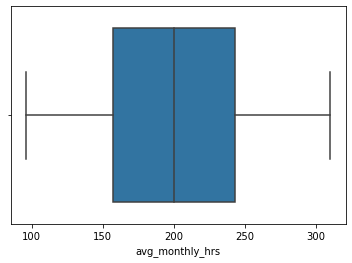

In [41]:
# Check for outliers. Using boxplot to visualize.

#sns.boxplot(x=df1['satisfaction_level'])  #skew left, no outlier
#sns.boxplot(x=df1['last_evaluation'])     #skew left, no outlier
#sns.boxplot(x=df1['number_project'])      #skew right, no outlier
sns.boxplot(x=df1['avg_monthly_hrs'])    

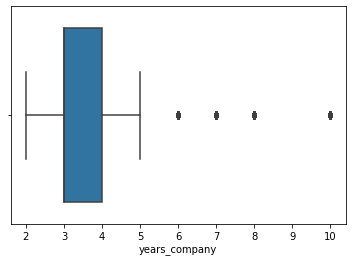

In [66]:
# Create a boxplot to visualize distribution of years of service and detect any outliers
sns.boxplot(x=df1['years_company'])


In [62]:
# Determine the number of rows containing outliers

q1 = df1['years_company'].quantile(0.25)
q3 = df1['years_company'].quantile(0.75)

iqr = q3 - q1
upper_limit = q3 + 1.5 * iqr
print('upper limit: ', upper_limit)

outliers = df1.loc[df1['years_company'] > upper_limit, 'years_company']
outliers


upper limit:  5.5


1         6
17        6
34        6
47        6
67        6
         ..
11994    10
11995    10
11996    10
11997    10
11998    10
Name: years_company, Length: 824, dtype: int64

In [12]:
# Check class imbalance
# Get numbers and % of people who left vs. stayed
print(df1['left'].value_counts())
print(df1['left'].value_counts(normalize=True))


0    10000
1     1991
Name: left, dtype: int64
0    0.833959
1    0.166041
Name: left, dtype: float64


Class imbalance but not extreme. Good to stratify when splitting data.

### 1b. Data visualizations

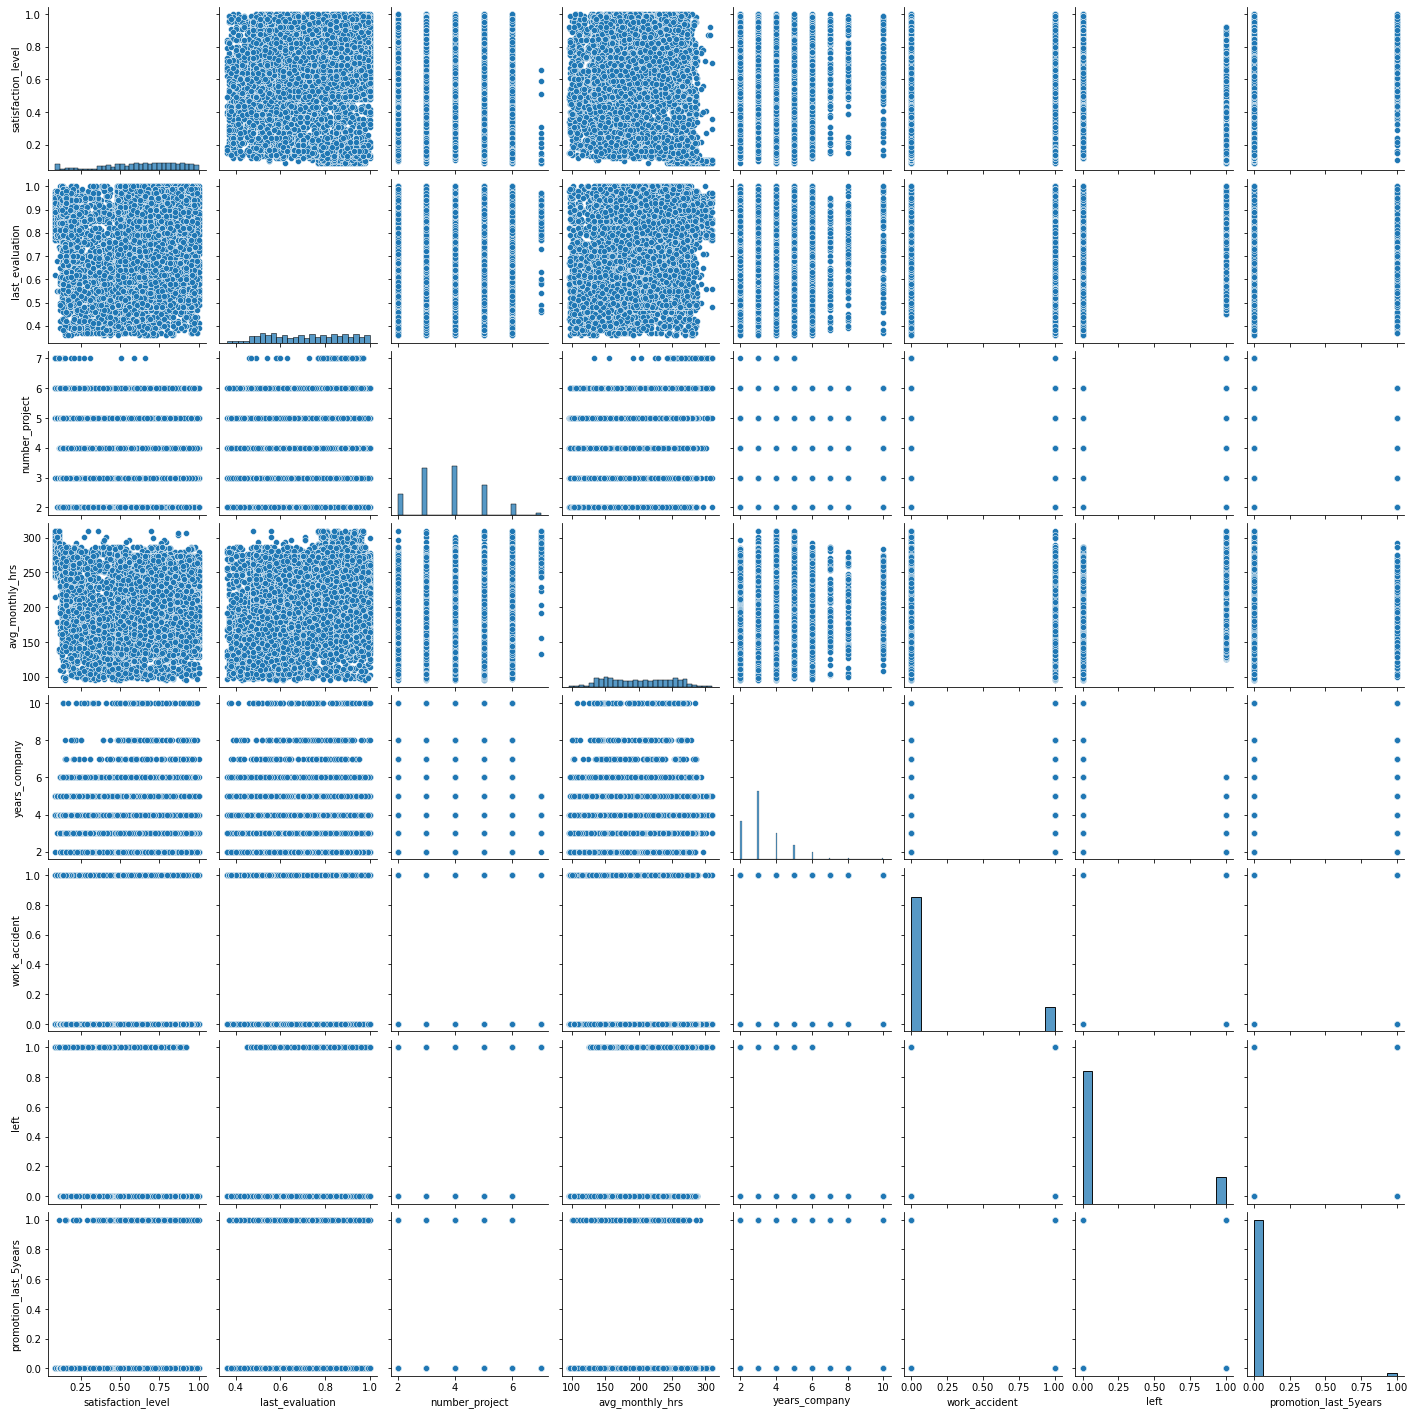

In [86]:
# Create pairwise scatterplots to visualize relationships between variables, to detect collinearity
sns.pairplot(df1)


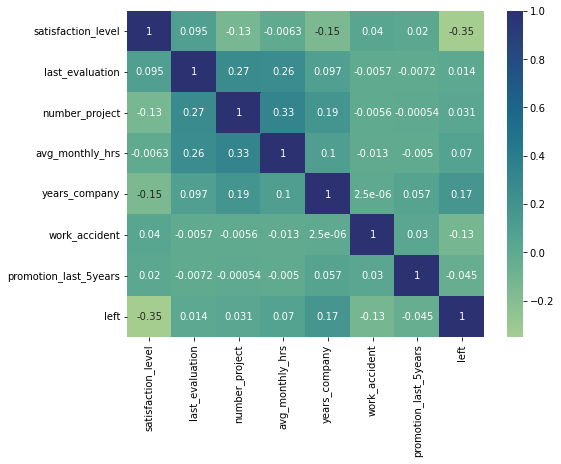

In [60]:
# Create heatmap to examine relationships between variables, values nearer to +/-1.0 indicate +/- strong correlation

plt.figure(figsize=(8,6))
sns.heatmap(df1[['satisfaction_level', 'last_evaluation', 'number_project',
       'avg_monthly_hrs', 'years_company', 'work_accident', 'promotion_last_5years','left']]
            .corr(),
           annot=True,
           cmap='crest')

plt.show()

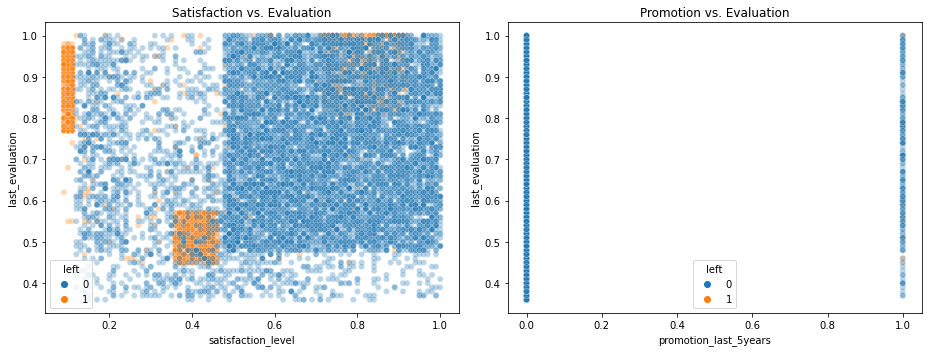

In [25]:
# Create sactterplots to examine some variables closer
fig, ax = plt.subplots(1,2, figsize=(13,5))

sns.scatterplot(df1['satisfaction_level'], df1['last_evaluation'], hue=df1['left'], alpha=.3, ax=ax[0])
ax[0].set_title('Satisfaction vs. Evaluation')

sns.scatterplot(df1['promotion_last_5years'], df1['last_evaluation'], hue=df1['left'], alpha=.3, ax=ax[1])
ax[1].set_title('Promotion vs. Evaluation')

plt.tight_layout()
plt.show()

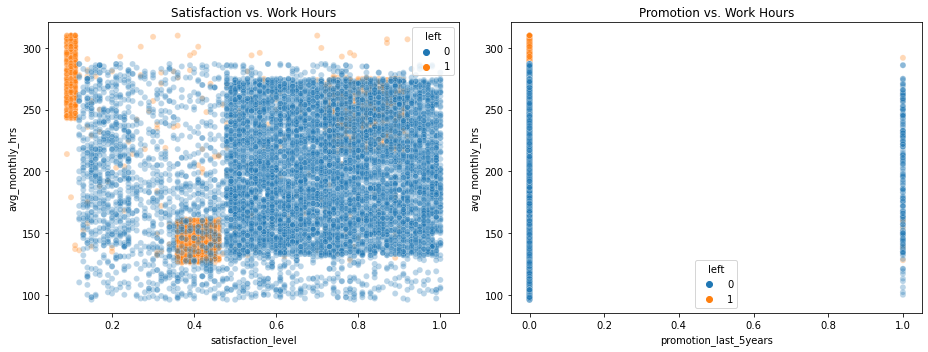

In [26]:
# Create sactterplots to examine some variables
fig, ax = plt.subplots(1,2, figsize=(13,5))

sns.scatterplot(df1['satisfaction_level'], df1['avg_monthly_hrs'], hue=df1['left'], alpha=.3, ax=ax[0])
ax[0].set_title('Satisfaction vs. Work Hours')

sns.scatterplot(df1['promotion_last_5years'], df1['avg_monthly_hrs'], hue=df1['left'], alpha=.3, ax=ax[1])
ax[1].set_title('Promotion vs. Work Hours')

plt.tight_layout()
plt.show()

In [83]:
# check out people who were not promoted and left - do they work long hours
df1.groupby(['left','promotion_last_5years'])[['avg_monthly_hrs']].agg([np.mean,np.median])

avg_monthly_hrs       
                                      mean median
left promotion_last_5years                       
0    0                          198.932585  198.0
     1                          199.451282  203.0
1    0                          208.281392  226.0
     1                          178.625000  157.0

In [79]:
# check out people who were not promoted and left - what's their satisfaction level
df1.groupby(['left','promotion_last_5years'])[['satisfaction_level']].agg([np.mean,np.median])

satisfaction_level       
                                         mean median
left promotion_last_5years                          
0    0                               0.667250  0.690
     1                               0.673128  0.700
1    0                               0.440061  0.410
     1                               0.492500  0.445

- People who were not promoted and left - lowest satisfaction, highest work hours (>200 hours on average monthly)

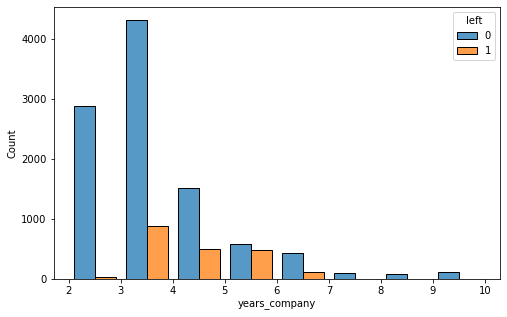

In [221]:
# Create histogram to check distribution by no. of years in the company
plt.figure(figsize=(8,5))
sns.histplot(df1, x='years_company', hue='left', multiple='dodge', binwidth=1, shrink=0.8)

- High turnover of employees at 3-6 years onwards. Significantly less employees above 3 years of service.

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], <a list of 10 Text major ticklabel objects>)

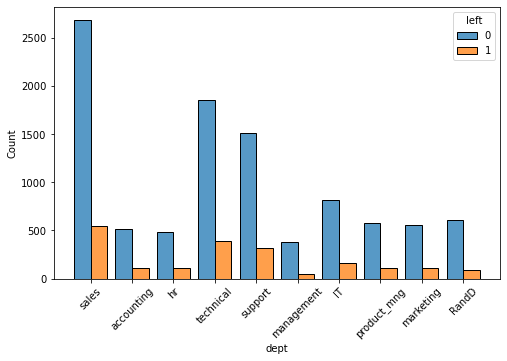

In [169]:
# Create histogram to check distribution by department
fig = plt.figure(figsize=(8,5))
sns.histplot(df1, x='dept', hue='left', multiple='dodge', shrink=0.8)
plt.xticks(rotation = 45)

Refer to summary report for insights.


### 2. Logistic Regression model

Logistic Regression model assumptions:
- Outcome variable is categorical
- Observations are independent of each other
- No severe multicollinearity among X variables
- No extreme outliers
- Linear relationship between each X variable and the logit of the outcome variable
- Sufficiently large sample size

In [65]:
# Filter out outliers as identified above during EDA
df_lr = df1[df1['years_company'] <= upper_limit].reset_index(drop = True) 
print(df_lr.shape)
df_lr.tail()

(11167, 10)


,satisfaction_level,last_evaluation,number_project,avg_monthly_hrs,years_company,work_accident,left,promotion_last_5years,dept,salary
11162,0.72,0.64,4,192,3,0,0,0,sales,medium
11163,0.48,0.50,5,142,4,0,0,0,IT,medium
11164,0.19,0.79,4,229,4,0,0,0,product_mng,medium
11165,0.62,0.85,3,237,3,1,0,0,IT,medium
11166,0.50,0.73,4,180,3,0,0,0,IT,low


In [66]:
# Convert 'depts' into 10 numeric columns with drop_first=False for easy reading since data size is computationally manageable
df_lr = pd.get_dummies(df_lr, columns=['dept'])

# Convert ordinal column into numeric
df_lr['salary'] = df_lr['salary'].map({"low": 1, "medium": 2, "high": 3})

#df_lr.dtypes
df_lr.head()

,satisfaction_level,last_evaluation,number_project,avg_monthly_hrs,years_company,work_accident,left,promotion_last_5years,salary,dept_IT,dept_RandD,dept_accounting,dept_hr,dept_management,dept_marketing,dept_product_mng,dept_sales,dept_support,dept_technical
0,0.38,0.53,2,157,3,0,1,0,1,0,0,0,0,0,0,0,1,0,0
1,0.11,0.88,7,272,4,0,1,0,2,0,0,0,0,0,0,0,1,0,0
2,0.72,0.87,5,223,5,0,1,0,1,0,0,0,0,0,0,0,1,0,0
3,0.37,0.52,2,159,3,0,1,0,1,0,0,0,0,0,0,0,1,0,0
4,0.41,0.50,2,153,3,0,1,0,1,0,0,0,0,0,0,0,1,0,0


In [69]:
# Create 70/30 train/test sets
X = df_lr.drop('left',axis=1)
y = df_lr['left']

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, stratify=y, random_state=0)

# Build a logistic regression model and fit the model to the training data
# Stack Overflow suggests using solver='liblinear' to overcome AttributeError: 'str' object has no attribute 'decode'
clf = LogisticRegression(solver='liblinear').fit(X_train,y_train)

In [70]:
# Get model parameters
print(X.columns)
print('coef: ', clf.coef_)
print('intercept: ', clf.intercept_)

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'avg_monthly_hrs', 'years_company', 'work_accident',
       'promotion_last_5years', 'salary', 'dept_IT', 'dept_RandD',
       'dept_accounting', 'dept_hr', 'dept_management', 'dept_marketing',
       'dept_product_mng', 'dept_sales', 'dept_support', 'dept_technical'],
      dtype='object')
coef:  [[-4.35872176e+00 -8.83710770e-02 -4.36629694e-01  3.24585095e-03
   1.02583699e+00 -1.45921646e+00 -4.85278058e-01 -5.07214405e-01
   2.68951379e-02 -3.07823645e-01 -1.70901174e-01  5.30719479e-02
  -1.95137118e-01 -3.98193459e-02 -1.12096882e-01  6.86662993e-02
  -3.78872499e-02  5.23445290e-02]]
intercept:  [-0.6626875]


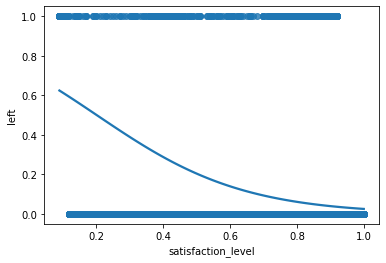

In [83]:
# Visualize relationship between the variables, line representing the best fit regression model
sns.regplot(x='satisfaction_level', y='left', data=df_lr, logistic=True, ci=None)

In [72]:
# Predict on test data
y_pred_lr = clf.predict(X_test)

# Use predict_proba to output a probability
#print(clf.predict_proba(X_test))

# Get evaluation metrics
print('Accuracy:', '%.6f' % accuracy_score(y_test, y_pred_lr))
print('Precision:', '%.6f' % precision_score(y_test, y_pred_lr))
print('Recall:', '%.6f' % recall_score(y_test, y_pred_lr))
print('F1:', '%.6f' % f1_score(y_test, y_pred_lr))
print('AUC:', '%.6f' % roc_auc_score(y_test, y_pred_lr))

Accuracy: 0.825724
Precision: 0.465704
Recall: 0.228319
F1: 0.306413
AUC: 0.587598


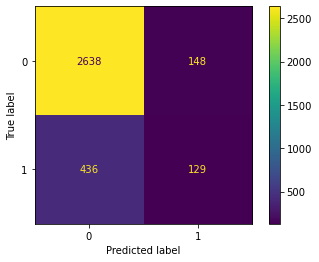

In [73]:
# Visualize model performance
cm = confusion_matrix(y_test, y_pred_lr, labels = clf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot(values_format='')

In [77]:
# Get classification_report
target_names = ['Predict-stay', 'Predict-leave']
print(classification_report(y_test, y_pred_lr, target_names=target_names))

               precision    recall  f1-score   support

 Predict-stay       0.86      0.95      0.90      2786
Predict-leave       0.47      0.23      0.31       565

     accuracy                           0.83      3351
    macro avg       0.66      0.59      0.60      3351
 weighted avg       0.79      0.83      0.80      3351



Logistic regression model
- Poor performance
- Precision, recall, f1, AUC scores are low.
- FP & FN are very high.

### 3a. Random forest model

Tree-based models are robust to outliers.

In [8]:
# df1 contains outliers
# convert 'depts' into 10 numeric columns. drop_first = False for easy 'dept' reading
df_ml = pd.get_dummies(df1, columns=['dept'])

# convert ordinal column into numeric
df_ml['salary'] = df_ml['salary'].map({"low": 1, "medium": 2, "high": 3})

#df_lr.dtypes
df_ml.head()

,satisfaction_level,last_evaluation,number_project,avg_monthly_hrs,years_company,work_accident,left,promotion_last_5years,salary,dept_IT,dept_RandD,dept_accounting,dept_hr,dept_management,dept_marketing,dept_product_mng,dept_sales,dept_support,dept_technical
0,0.38,0.53,2,157,3,0,1,0,1,0,0,0,0,0,0,0,1,0,0
1,0.80,0.86,5,262,6,0,1,0,2,0,0,0,0,0,0,0,1,0,0
2,0.11,0.88,7,272,4,0,1,0,2,0,0,0,0,0,0,0,1,0,0
3,0.72,0.87,5,223,5,0,1,0,1,0,0,0,0,0,0,0,1,0,0
4,0.37,0.52,2,159,3,0,1,0,1,0,0,0,0,0,0,0,1,0,0


In [9]:
# Create 60/20/20 train/validation/test sets
X = df_ml.drop('left',axis=1)
y = df_ml['left']

X_train_val, X_test, y_train_val, y_test = train_test_split(X,y, test_size=0.2, stratify=y, random_state=0)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size = 0.25, random_state = 0)

X_train.shape, X_val.shape, X_test.shape, y_train.shape, y_val.shape, y_test.shape

((7194, 18), (2398, 18), (2399, 18), (7194,), (2398,), (2399,))

In [10]:
# Define parameters for tuning
cv_params = {'n_estimators' : [100],
             'max_depth' : [None],       
             #'max_samples' : [.5,.9],
             'max_features' : [10],
             'min_samples_leaf' : [2],
             'min_samples_split' : [1,2]
            }

# Define scoring metrics
scoring = ['accuracy', 'precision', 'recall', 'f1']

# Specify data for validation using split indices, for class imbalance (but potential overfitting)
split_index = [0 if x in X_val.index else -1 for x in X_train_val.index]
custom_split = PredefinedSplit(split_index)

# Instantiate model
rf = RandomForestClassifier(random_state=0)

# Search over specified parameters
rf_cv = GridSearchCV(rf, cv_params, scoring=scoring, cv=custom_split, refit='f1')   # n_jobs = -1, verbose = 1)


In [11]:
%time

# Fit the model
rf_cv.fit(X_train_val, y_train_val)

CPU times: user 3 µs, sys: 2 µs, total: 5 µs
Wall time: 9.3 µs


GridSearchCV(cv=PredefinedSplit(test_fold=array([-1, -1, ..., -1,  0])),
             error_score=nan,
             estimator=RandomForestClassifier(bootstrap=True, ccp_alpha=0.0,
                                              class_weight=None,
                                              criterion='gini', max_depth=None,
                                              max_features='auto',
                                              max_leaf_nodes=None,
                                              max_samples=None,
                                              min_impurity_decrease=0.0,
                                              min_impurity_split=None,
                                              min_samples_leaf=1,
                                              min_samples_split=2,
                                              min_weigh...
                                              n_estimators=100, n_jobs=None,
                                              oob_score=False, r

In [12]:
# Check best score
print(rf_cv.best_score_)

# Check best parameters
rf_cv.best_params_

0.9546599496221662


{'max_depth': None,
 'max_features': 10,
 'min_samples_leaf': 2,
 'min_samples_split': 2,
 'n_estimators': 100}

               precision    recall  f1-score   support

 Predict-stay       0.99      1.00      0.99      1984
Predict-leave       1.00      0.94      0.97       414

     accuracy                           0.99      2398
    macro avg       0.99      0.97      0.98      2398
 weighted avg       0.99      0.99      0.99      2398



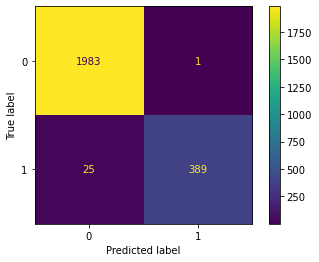

In [17]:
# Use rf best estimator model to get predictions on validation set
y_pred_rf = rf_cv.best_estimator_.predict(X_val)

# Evaluate metrics & performance
target_names = ['Predict-stay', 'Predict-leave']
print(classification_report(y_val, y_pred_rf, target_names=target_names))

# Visualize performance
cm = confusion_matrix(y_val, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf_cv.classes_)
disp.plot(values_format='')

In [18]:
# Using cv=5 instead of separate validation set for tuning, less susceptible to overfitting
rf_cv5 = GridSearchCV(rf, cv_params, scoring=scoring, cv=5, refit='f1')
# Fit the model
rf_cv5.fit(X_train, y_train)

GridSearchCV(cv=5, error_score=nan,
             estimator=RandomForestClassifier(bootstrap=True, ccp_alpha=0.0,
                                              class_weight=None,
                                              criterion='gini', max_depth=None,
                                              max_features='auto',
                                              max_leaf_nodes=None,
                                              max_samples=None,
                                              min_impurity_decrease=0.0,
                                              min_impurity_split=None,
                                              min_samples_leaf=1,
                                              min_samples_split=2,
                                              min_weight_fraction_leaf=0.0,
                                              n_estimators=100, n_jobs=None,
                                              oob_score=False, random_state=0,
                                   

In [22]:
# Check best score
print('rf_cv5 best score: ', rf_cv5.best_score_)

rf_cv5 best score:  0.9497718629975459


               precision    recall  f1-score   support

 Predict-stay       0.98      1.00      0.99      1984
Predict-leave       1.00      0.92      0.95       414

     accuracy                           0.98      2398
    macro avg       0.99      0.96      0.97      2398
 weighted avg       0.99      0.98      0.98      2398



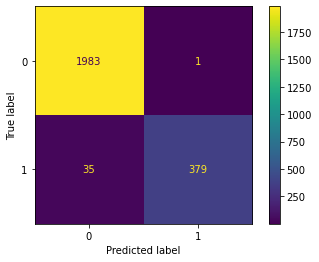

In [23]:
# Use rf_cv5 best estimator model to get predictions on validation set
y_pred_rf5 = rf_cv5.best_estimator_.predict(X_val)

# Evaluate metrics & performance
target_names = ['Predict-stay', 'Predict-leave']
print(classification_report(y_val, y_pred_rf5, target_names=target_names))

# Visualize performance
cm = confusion_matrix(y_val, y_pred_rf5)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf_cv.classes_)
disp.plot(values_format='')

Text(0.5, 1.0, 'Feature importance')

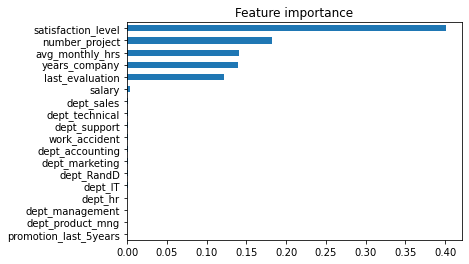

In [147]:
# Check feature importance of rf_cv best estimator
importances = rf_cv.best_estimator_.feature_importances_

rf_importances = pd.Series(importances, index=X.columns).sort_values()
rf_importances.plot.barh()
plt.title('Feature importance')

Random forest model
- Performance scores well
- Note: FN > FP
- 5 significant features



### 3b. XGBoost model


In [151]:
# Instantiate XGBClassifier
xgb = XGBClassifier(objective='binary:logistic', random_state=0)

# Define parameters for tuning
cv_params = {'max_depth': [6],
             'min_child_weight': [2],
             'learning_rate': [0.1],
             'n_estimators': [100],
             'subsample': [0.7],
             'colsample_bytree': [0.7]
            }

# Define scoring metrics
scoring = ['accuracy', 'precision', 'recall', 'f1']

# Search over specified parameters
xgb_cv = GridSearchCV(xgb, cv_params, scoring=scoring, cv=custom_split, refit='f1')

In [152]:
%%time

# Fit the model
#xgb_cv.fit(X_train, y_train)
xgb_cv.fit(X_train_val, y_train_val)

CPU times: user 2min 1s, sys: 159 ms, total: 2min 1s
Wall time: 1min


GridSearchCV(cv=PredefinedSplit(test_fold=array([-1, -1, ..., -1,  0])),
             error_score=nan,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     gamma=None, gpu_id=None, grow_policy=None,
                                     importance_type=None,
                                     in...
                                     objective='binary:logistic',
                                     predictor=None, random_state=0,
                                     reg_alpha=None, ...),
             iid='deprecated', n_jobs=None,
             param_grid={'colsample_bytree': [0.7], 'learning_rate

In [153]:
# Check best score
print(xgb_cv.best_score_)

# Check best parameters
xgb_cv.best_params_

0.951188986232791


{'colsample_bytree': 0.7,
 'learning_rate': 0.1,
 'max_depth': 6,
 'min_child_weight': 2,
 'n_estimators': 100,
 'subsample': 0.7}

In [154]:
# Pickle xgb model
'''
{'colsample_bytree': 0.7,
 'learning_rate': 0.1,
 'max_depth': 6,
 'min_child_weight': 2,
 'n_estimators': 100,
 'subsample': 0.7}
'''
#with open('xgb_cv_customsplit.pickle', 'wb') as write:
#    pickle.dump(xgb_cv, write)


# Open pickled model xgb
with open('xgb_cv_customsplit.pickle', 'rb') as read:
   xgb_cv = pickle.load(read)

               precision    recall  f1-score   support

 Predict-stay       0.99      1.00      0.99      1984
Predict-leave       1.00      0.93      0.96       414

     accuracy                           0.99      2398
    macro avg       0.99      0.96      0.98      2398
 weighted avg       0.99      0.99      0.99      2398



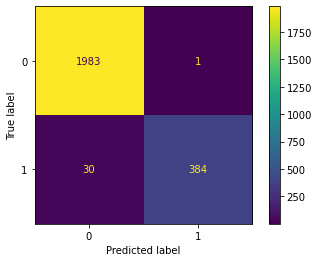

In [156]:
# Use xgb best estimator model to get predictions on validation set
y_pred_xgb = xgb_cv.best_estimator_.predict(X_val)

# Evaluate metrics & performance
print(classification_report(y_val, y_pred_xgb, target_names=target_names))

# Visualize model performance
cm = confusion_matrix(y_val, y_pred_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels=xgb_cv.classes_)
disp.plot(values_format='')

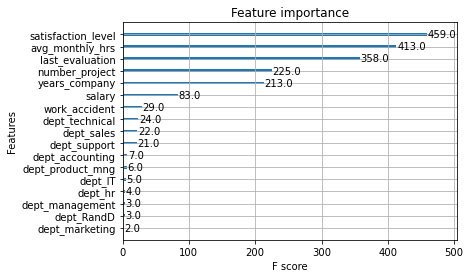

In [157]:
# Check feature importance
plot_importance(xgb_cv.best_estimator_)

**RF model** performs slightly better than XGB model, and requires less computational time/cost.


### 4. Summary of results

               precision    recall  f1-score   support

 Predict-stay       0.98      1.00      0.99      2001
Predict-leave       0.99      0.91      0.95       398

     accuracy                           0.98      2399
    macro avg       0.98      0.95      0.97      2399
 weighted avg       0.98      0.98      0.98      2399



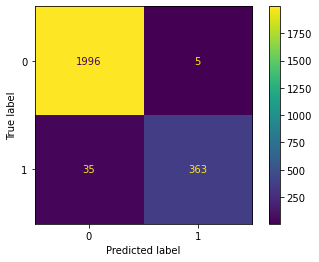

In [28]:
# Fit 'champion' model to test data
y_pred = rf_cv.best_estimator_.predict(X_test)

target_names = ['Predict-stay', 'Predict-leave']
print(classification_report(y_test, y_pred, target_names=target_names))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels=rf_cv.classes_)
disp.plot(values_format='')

- 5 false positives: Model predicts employee is leaving when it is not true 
→ incur retention costs and does not offer high value outcome
- 35 false negatives: Model predicts employee is staying when it is not true 
→ employee departure due to no retention action, incur hiring & retraining costs

**Benefits & limitations**
- The random forest model is fairly good in prediction.
- The RF model requires less computational time/cost (as compared to XGB).
- However, there could be a handful of employees who are not predicted to leave when in fact they are leaving (false negatives).


---
---
---

### Just-curious: changing target variable to 'satisfaction_level'

To improve/predict employee 'satisfaction_level' (continuous variable) and check out what could influence their satisfaction.

In [2]:
# import for Random Forest Regression, for y is continuous
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics

In [12]:
# convert 'depts' into 10 numeric columns with drop_first = False for easy 'dept' reading
df_mlrg = pd.get_dummies(df1, columns=['dept'])

# convert ordinal column into numeric
df_mlrg['salary'] = df_mlrg['salary'].map({"low": 1, "medium": 2, "high": 3})

#df_lr.dtypes
df_mlrg.head()

,satisfaction_level,last_evaluation,number_project,avg_monthly_hrs,years_company,work_accident,left,promotion_last_5years,salary,dept_IT,dept_RandD,dept_accounting,dept_hr,dept_management,dept_marketing,dept_product_mng,dept_sales,dept_support,dept_technical
0,0.38,0.53,2,157,3,0,1,0,1,0,0,0,0,0,0,0,1,0,0
1,0.80,0.86,5,262,6,0,1,0,2,0,0,0,0,0,0,0,1,0,0
2,0.11,0.88,7,272,4,0,1,0,2,0,0,0,0,0,0,0,1,0,0
3,0.72,0.87,5,223,5,0,1,0,1,0,0,0,0,0,0,0,1,0,0
4,0.37,0.52,2,159,3,0,1,0,1,0,0,0,0,0,0,0,1,0,0


In [14]:
# Create 60/20/20 train/validation/test sets
X = df_mlrg.drop('satisfaction_level',axis=1)
y = df_mlrg['satisfaction_level']

X_train_val, X_test, y_train_val, y_test = train_test_split(X,y, test_size=0.2, stratify=y, random_state=0)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size = 0.25, random_state = 0)

X_train.shape, X_val.shape, X_test.shape, y_train.shape, y_val.shape, y_test.shape

((7194, 18), (2398, 18), (2399, 18), (7194,), (2398,), (2399,))

In [31]:
# Define parameters for tuning and instantiate model
cv_params = {'n_estimators' : [200],
             'max_depth' : [5],       
             #'max_features' : [10, 16],
             'min_samples_leaf' : [2],
             'min_samples_split' : [2]
            }

rfrg = RandomForestRegressor(n_estimators=100, random_state=0)
rfrg_cv = GridSearchCV(rfrg, cv_params, scoring='neg_mean_squared_error', cv=5, refit=True)

In [32]:
%%time

# Fit the model
rfrg_cv.fit(X_train, y_train)

CPU times: user 10.9 s, sys: 31.3 ms, total: 10.9 s
Wall time: 10.9 s


GridSearchCV(cv=5, error_score=nan,
             estimator=RandomForestRegressor(bootstrap=True, ccp_alpha=0.0,
                                             criterion='mse', max_depth=None,
                                             max_features='auto',
                                             max_leaf_nodes=None,
                                             max_samples=None,
                                             min_impurity_decrease=0.0,
                                             min_impurity_split=None,
                                             min_samples_leaf=1,
                                             min_samples_split=2,
                                             min_weight_fraction_leaf=0.0,
                                             n_estimators=100, n_jobs=None,
                                             oob_score=False, random_state=0,
                                             verbose=0, warm_start=False),
             iid='deprecated', n_jobs=

In [33]:
# check best score, closer to zero (a smaller absolute value) is better
print(rfrg_cv.best_score_)

# check best parameters
rfrg_cv.best_params_

-0.0359615846054592


{'max_depth': 5,
 'min_samples_leaf': 2,
 'min_samples_split': 2,
 'n_estimators': 200}

In [35]:
# Use random forest "best estimator" model to get predictions on validation set
y_pred_rg = rfrg_cv.best_estimator_.predict(X_val)

# metrics - lower better
print('Mean Absolute Error (MAE):', metrics.mean_absolute_error(y_val, y_pred_rg))
print('Mean Squared Error (MSE):', metrics.mean_squared_error(y_val, y_pred_rg))
print('Root Mean Squared Error (RMSE):', np.sqrt(metrics.mean_squared_error(y_val, y_pred_rg)))
print('Mean Absolute Error (MAE):', metrics.mean_absolute_error(y_val, y_pred_rg))

# metrics - higher 1.0 better
print('R-squared, Coefficient of Determination:', metrics.r2_score(y_val, y_pred_rg))

# r2 < 0.5: May indicate that the model is not capturing 
#a significant amount of the underlying relationship 

Mean Absolute Error (MAE): 0.14525074428331397
Mean Squared Error (MSE): 0.03568941211537332
Root Mean Squared Error (RMSE): 0.1889164156852795
Mean Absolute Error (MAE): 0.14525074428331397
R-squared, Coefficient of Determination: 0.38310520427779915


Text(0.5, 1.0, 'RF Regression Feature importance')

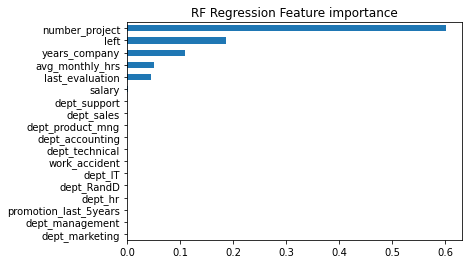

In [36]:
# plot tree for rf best_estimator_
importances = rfrg_cv.best_estimator_.feature_importances_

rfrg_importances = pd.Series(importances, index=X.columns).sort_values()
rfrg_importances.plot.barh()
plt.title('RF Regression Feature importance')

In [38]:
# try XGBoost regression
from xgboost import XGBRegressor

In [53]:
# Define parameters for tuning
cv_params = {'max_depth': [6],
             'min_child_weight': [2],
             'learning_rate': [0.1],
             'n_estimators': [100],
             'subsample': [0.7],
             'colsample_bytree': [0.7]
            }

xgbrg = XGBRegressor(objective='reg:squarederror', random_state=0)

xgbrg_cv = GridSearchCV(xgbrg, cv_params, scoring='neg_mean_squared_error', cv=5, refit=True)

In [56]:
%%time

# Fit the model
xgbrg_cv.fit(X_train, y_train)

CPU times: user 15min 38s, sys: 2.62 s, total: 15min 41s
Wall time: 7min 51s


GridSearchCV(cv=5, error_score=nan,
             estimator=XGBRegressor(base_score=0.5, booster='gbtree',
                                    callbacks=None, colsample_bylevel=1,
                                    colsample_bynode=1, colsample_bytree=1,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    gamma=0, gpu_id=-1, grow_policy='depthwise',
                                    importance_type=None,
                                    interaction_constraints='',
                                    learning_rate=0.300000012, max...
                                    n_jobs=0, num_parallel_tree=1,
                                    objective='reg:squarederror',
                                    predictor='auto', random_state=0,
                                    reg_alpha=0, ...),
             iid='deprecated', n_jobs=None,
             param_grid={'

In [58]:
# check best score, closer to zero (a smaller absolute value) is better
print(xgbrg_cv.best_score_)

# check best parameters
xgbrg_cv.best_params_

-0.035933355994421066


{'colsample_bytree': 0.7,
 'learning_rate': 0.1,
 'max_depth': 6,
 'min_child_weight': 2,
 'n_estimators': 100,
 'subsample': 0.7}

In [60]:
# Use random forest "best estimator" model to get predictions on validation set
y_pred_xrg = xgbrg_cv.best_estimator_.predict(X_val)

# metrics - lower better
print('Mean Absolute Error (MAE):', metrics.mean_absolute_error(y_val, y_pred_xrg))
print('Mean Squared Error (MSE):', metrics.mean_squared_error(y_val, y_pred_xrg))
print('Root Mean Squared Error (RMSE):', np.sqrt(metrics.mean_squared_error(y_val, y_pred_xrg)))
print('Mean Absolute Error (MAE):', metrics.mean_absolute_error(y_val, y_pred_xrg))

# metrics - higher 1.0 better
print('R-squared, Coefficient of Determination:', metrics.r2_score(y_val, y_pred_xrg))

# r2 < 0.5: May indicate that the model is not capturing 
#a significant amount of the underlying relationship 

Mean Absolute Error (MAE): 0.14585759001401088
Mean Squared Error (MSE): 0.03567707245705098
Root Mean Squared Error (RMSE): 0.18888375381977926
Mean Absolute Error (MAE): 0.14585759001401088
R-squared, Coefficient of Determination: 0.3833184964154067


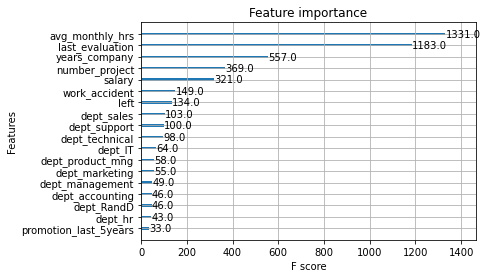

In [61]:
plot_importance(xgbrg_cv.best_estimator_)

RF best estimator model gives R-squared score of 0.38:
- model explains 38% of the variance in the target variable
- some predictive power but a significant portion of 62% of the variability is unexplained
- feature importance reveals the factors that could influence employees' statisfaction

---
---
---
🤔 How about gathering more features data such as - rating for supervisor, motivation level?